In [1]:
# ================================================================
#  COMPLETE KAGGLE NOTEBOOK — Cell by Cell
#  Hindi Speech → English Speech Translation
#  Copy each cell into Kaggle in order
# ================================================================


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Install Libraries
# ══════════════════════════════════════════════════════════════
!pip install -q torch torchaudio transformers sentencepiece \
    datasets librosa soundfile jiwer sacrebleu scipy \
    huggingface_hub
print("✅ All libraries installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 45.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 2.8 MB/s eta 0:00:00
✅ All libraries installed


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Setup Environment
# ══════════════════════════════════════════════════════════════
import os, sys, torch

WORK_DIR = "/kaggle/working"
os.makedirs(f"{WORK_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{WORK_DIR}/logs",        exist_ok=True)
os.makedirs(f"{WORK_DIR}/output",      exist_ok=True)

sys.path.insert(0, WORK_DIR)
os.chdir(WORK_DIR)

print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")


PyTorch : 2.10.0+cu128
GPU     : True
GPU name: Tesla T4


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Copy Your 6 Source Files
# (Upload config.py, tokenizer.py, dataset.py,
#  models.py, trainer.py, pipeline.py to Kaggle Dataset first)
# ══════════════════════════════════════════════════════════════
import shutil

INPUT_DATASET = "/kaggle/input/datasets/fa1zi2ah/conversion-file"  # ← your path

for f in ["config.py", "tokenizer.py", "dataset.py",
          "models.py", "trainer.py", "pipeline.py"]:
    shutil.copy(os.path.join(INPUT_DATASET, f),
                os.path.join(WORK_DIR, f))
    print(f"  Copied: {f}")

print("✅ All source files ready")

  Copied: config.py
  Copied: tokenizer.py
  Copied: dataset.py
  Copied: models.py
  Copied: trainer.py
  Copied: pipeline.py
✅ All source files ready


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Import All Modules
# ══════════════════════════════════════════════════════════════
from config    import AudioConfig as AC, TrainConfig as TC, DEVICE
from tokenizer import HindiTokenizer, EnglishTokenizer
from dataset   import ASRDataset, asr_collate, TTSDataset, tts_collate
from models    import ASRModel, TTSModel
from trainer   import train_asr, train_tts

print("✅ All modules imported")
print(f"   Device : {DEVICE}")

✅ All modules imported
   Device : cuda


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Download Kathbath Parquet Files from HuggingFace
# (Downloads raw parquet files — bypasses torchcodec crash)
# ══════════════════════════════════════════════════════════════
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, hf_hub_download

hf_token = UserSecretsClient().get_secret("HF_TOKEN")
login(token=hf_token)
print("✅ HuggingFace login successful")

CACHE = "/kaggle/working/kathbath_parquet"
os.makedirs(CACHE, exist_ok=True)

parquet_files = []
# ← change range(5) to range(28) for full dataset
for i in range(5):
    fname = f"hindi/train-{str(i).zfill(5)}-of-00032.parquet"
    try:
        path = hf_hub_download(
            repo_id   = "ai4bharat/kathbath",
            filename  = fname,
            repo_type = "dataset",
            token     = hf_token,
            cache_dir = CACHE,
        )
        parquet_files.append(path)
        print(f"  ✅  {fname}")
    except Exception as e:
        print(f"  ⚠️  {fname} — {e}")

print(f"\n✅ Downloaded {len(parquet_files)} parquet files")


✅ HuggingFace login successful


hindi/train-00000-of-00032.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

  ✅  hindi/train-00000-of-00032.parquet


hindi/train-00001-of-00032.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

  ✅  hindi/train-00001-of-00032.parquet


...

  ✅  hindi/train-00002-of-00032.parquet


hindi/train-00003-of-00032.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

  ✅  hindi/train-00003-of-00032.parquet


hindi/train-00004-of-00032.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

  ✅  hindi/train-00004-of-00032.parquet

✅ Downloaded 5 parquet files


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Build Samples from Parquet Files
# (Reads audio bytes directly — no torchcodec)
# ══════════════════════════════════════════════════════════════
import pandas as pd
import torch, torchaudio, io
import torchaudio.transforms as T

samples = []
skipped = 0

for file in parquet_files:
    print(f"Loading {os.path.basename(file)} ...")
    df = pd.read_parquet(file)

    for _, row in df.iterrows():
        try:
            # Get audio bytes
            audio_val = row["audio_filepath"]
            if isinstance(audio_val, dict) and "bytes" in audio_val:
                raw_bytes = audio_val["bytes"]
            elif isinstance(audio_val, bytes):
                raw_bytes = audio_val
            else:
                skipped += 1
                continue

            if not raw_bytes:
                skipped += 1
                continue

            # Load audio
            waveform, sr = torchaudio.load(io.BytesIO(raw_bytes))

            # Stereo to mono
            if waveform.shape[0] > 1:
                waveform = waveform.mean(0, keepdim=True)
            waveform = waveform.squeeze(0)

            # Resample to 16kHz
            if sr != 16000:
                waveform = T.Resample(sr, 16000)(
                    waveform.unsqueeze(0)
                ).squeeze(0)

            # Get transcript
            text_col = next(
                (c for c in ["text", "transcript", "sentence"]
                 if c in df.columns), None
            )
            if text_col is None:
                skipped += 1
                continue

            text = str(row[text_col]).strip().upper()
            if not text:
                skipped += 1
                continue

            samples.append({
                "waveform"  : waveform,
                "sr"        : 16000,
                "transcript": text,
            })

        except:
            skipped += 1

print(f"\n✅ Loaded  : {len(samples)}")
print(f"⚠️  Skipped : {skipped}")
print(f"Example   : {samples[0]['transcript']}")
print(f"Shape     : {samples[0]['waveform'].shape}")


Loading train-00000-of-00032.parquet ...
Loading train-00001-of-00032.parquet ...
Loading train-00002-of-00032.parquet ...
Loading train-00003-of-00032.parquet ...
Loading train-00004-of-00032.parquet ...

✅ Loaded  : 14340
⚠️  Skipped : 0
Example   : हालांकि चिकित्सकों ने जेसीओ की मौत हार्ट अटैक से हुई बताया है
Shape     : torch.Size([79877])


In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Build Hindi Tokenizer and ASR Dataset
# ══════════════════════════════════════════════════════════════
from tokenizer import HindiTokenizer
from dataset   import ASRDataset, asr_collate

hi_tok = HindiTokenizer()
hi_tok.build_vocab([s["transcript"] for s in samples])
print(f"Vocab size    : {hi_tok.vocab_size}")

asr_dataset = ASRDataset(samples, hi_tok, augment=True)
feat, label = asr_dataset[2]
print(f"Feature shape : {feat.shape}")   # should be (120, T)
print(f"Label shape   : {label.shape}")
print(f"Label decoded : {hi_tok.decode(label.tolist())}")
print("✅ ASR Dataset ready")



[HindiTokenizer] Vocab size: 73
Vocab size    : 73
Feature shape : torch.Size([120, 583])
Label shape   : torch.Size([67])
Label decoded : क्योंकि लोगों को एकत्रित करने पर पंजाब सरकार की ही मनाही लगी हुई है
✅ ASR Dataset ready


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Create ASR DataLoaders
# ══════════════════════════════════════════════════════════════
from torch.utils.data import DataLoader, random_split
from config import TrainConfig as TC

n_val   = max(1, int(len(asr_dataset) * 0.1))
n_train = len(asr_dataset) - n_val
asr_train, asr_val = random_split(asr_dataset, [n_train, n_val])

asr_train_loader = DataLoader(
    asr_train,
    batch_size  = TC.ASR_BATCH_SIZE,
    shuffle     = True,
    collate_fn  = asr_collate,
    num_workers = 2,
    pin_memory  = True,
)
asr_val_loader = DataLoader(
    asr_val,
    batch_size  = TC.ASR_BATCH_SIZE,
    shuffle     = False,
    collate_fn  = asr_collate,
    num_workers = 2,
    pin_memory  = True,
)

print(f"Train samples : {n_train}")
print(f"Val samples   : {n_val}")
print(f"Train batches : {len(asr_train_loader)}")
print(f"Val batches   : {len(asr_val_loader)}")
print("✅ ASR DataLoaders ready")



Train samples : 12906
Val samples   : 1434
Train batches : 807
Val batches   : 90
✅ ASR DataLoaders ready


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Train ASR Model
# ══════════════════════════════════════════════════════════════
from models  import ASRModel
from trainer import train_asr
from config  import TrainConfig as TC, DEVICE

TC.ASR_EPOCHS = 30   # ← change this number
TC.PATIENCE   = 10

print(f"Device     : {DEVICE}")
print(f"Epochs     : {TC.ASR_EPOCHS}")
print(f"Vocab size : {hi_tok.vocab_size}")

asr_model = ASRModel(feature_dim=120, vocab_size=hi_tok.vocab_size)
print(f"Parameters : {sum(p.numel() for p in asr_model.parameters()):,}")

train_asr(asr_model, asr_train_loader, asr_val_loader, hi_tok)

hi_tok.save("/kaggle/working/checkpoints/hindi_tokenizer.json")
print("✅ ASR training complete")


Device     : cuda
Epochs     : 30
Vocab size : 73
Parameters : 25,163,913

  ASR Training
  Parameters  : 25,163,913
  Device      : cuda
  Epochs      : 30
  Warmup steps: 1000
  Peak LR     : 0.0003
  Vocab size  : 73
  [01] step 0800/0807 | loss 4.1182 | lr 8.00e-055
  Epoch 01/30 | Train 4.1000 | Val 1.9446 | WER 96.3% | LR 8.07e-05 | 941s
  ✅  Saved asr_best.pt  (epoch 1, loss 1.9446)
  [02] step 0800/0807 | loss 1.5204 | lr 9.98e-05
  Epoch 02/30 | Train 1.5184 | Val 1.1564 | WER 78.8% | LR 9.98e-05 | 951s
  ✅  Saved asr_best.pt  (epoch 2, loss 1.1564)
  [03] step 0800/0807 | loss 1.0748 | lr 9.91e-05
  Epoch 03/30 | Train 1.0735 | Val 0.9045 | WER 66.0% | LR 9.91e-05 | 958s
  ✅  Saved asr_best.pt  (epoch 3, loss 0.9045)
  [04] step 0800/0807 | loss 0.8717 | lr 9.78e-05
  Epoch 04/30 | Train 0.8711 | Val 0.7906 | WER 60.2% | LR 9.77e-05 | 952s
  ✅  Saved asr_best.pt  (epoch 4, loss 0.7906)
  [05] step 0800/0807 | loss 0.7438 | lr 9.59e-05
  Epoch 05/30 | Train 0.7434 | Val 0.7004

In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Test Helsinki-NLP Translation Model
# ══════════════════════════════════════════════════════════════
import torch
from transformers import MarianMTModel, MarianTokenizer

print("Loading Helsinki-NLP Hindi→English ...")
trans_tok   = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
trans_model = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-hi-en").to(DEVICE)
trans_model.eval()

def translate(hindi_text):
    if not hindi_text.strip():
        return "hello"
    inputs = trans_tok(
        [hindi_text], return_tensors="pt",
        padding=True, truncation=True, max_length=256,
    ).to(DEVICE)
    with torch.no_grad():
        out = trans_model.generate(**inputs, max_length=256)
    return trans_tok.decode(out[0], skip_special_tokens=True)

# Test
tests = [
    "नमस्ते आप कैसे हैं",
    "आज मौसम बहुत अच्छा है",
    "हमने उसका जन्मदिन मनाया",
]
print("\nTranslation test:")
print("-" * 40)
for h in tests:
    print(f"Hindi   : {h}")
    print(f"English : {translate(h)}\n")

print("✅ Translation model ready")


Loading Helsinki-NLP Hindi→English ...


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/304M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


Translation test:
----------------------------------------
Hindi   : नमस्ते आप कैसे हैं
English : Hello how you are.

Hindi   : आज मौसम बहुत अच्छा है
English : The Weather Is Very Good Today

Hindi   : हमने उसका जन्मदिन मनाया
English : We celebrated his birthday.

✅ Translation model ready


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Download LJSpeech TTS Dataset
# ══════════════════════════════════════════════════════════════
import os

LJ_PATH = "/kaggle/working/data/tts/LJSpeech-1.1"

if not os.path.exists(os.path.join(LJ_PATH, "metadata.csv")):
    print("Downloading LJSpeech (2.6 GB) ...")
    os.makedirs("/kaggle/working/data/tts", exist_ok=True)
    !wget -q --show-progress \
        https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2 \
        -O /kaggle/working/LJSpeech.tar.bz2
    !tar -xf /kaggle/working/LJSpeech.tar.bz2 -C /kaggle/working/data/tts/
    !rm /kaggle/working/LJSpeech.tar.bz2
    print("✅ LJSpeech downloaded")
else:
    print("✅ LJSpeech already exists")

print(os.listdir(LJ_PATH))

/kaggle/working/LJS 100%[===================>]   2.56G   273MB/s    in 11s     
✅ LJSpeech downloaded
['metadata.csv', 'wavs', 'README']


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Build TTS Dataset and DataLoaders
# ══════════════════════════════════════════════════════════════
from tokenizer  import EnglishTokenizer
from dataset    import TTSDataset, tts_collate
from torch.utils.data import DataLoader, random_split, Subset

eng_tok  = EnglishTokenizer()
tts_full = TTSDataset(LJ_PATH, eng_tok, max_samples=3000)
print(f"English vocab : {eng_tok.vocab_size}")
print(f"TTS samples   : {len(tts_full)}")

n_val   = max(1, int(len(tts_full) * 0.05))
n_train = len(tts_full) - n_val
tts_train, tts_val = random_split(tts_full, [n_train, n_val])

tts_train_loader = DataLoader(
    tts_train,
    batch_size  = TC.TTS_BATCH_SIZE,
    shuffle     = True,
    collate_fn  = tts_collate,
    num_workers = 2,
    pin_memory  = True,
)
tts_val_loader = DataLoader(
    tts_val,
    batch_size  = TC.TTS_BATCH_SIZE,
    shuffle     = False,
    collate_fn  = tts_collate,
    num_workers = 2,
    pin_memory  = True,
)

print(f"Train batches : {len(tts_train_loader)}")
print(f"Val batches   : {len(tts_val_loader)}")
print("✅ TTS DataLoaders ready")


[EnglishTokenizer] Vocab size: 80
[TTSDataset] 3000 samples loaded
English vocab : 80
TTS samples   : 3000
Train batches : 179
Val batches   : 10
✅ TTS DataLoaders ready


In [14]:
# # ── Load ASR (your trained model) ────────────────────────────
# import torch
# from tokenizer import HindiTokenizer
# from models    import ASRModel
# from dataset   import FeatureExtractor
# from config    import DEVICE

# hi_tok2   = HindiTokenizer().load(
#     "/kaggle/working/checkpoints/hindi_tokenizer.json"
# )
# asr_ckpt  = torch.load(
#     "/kaggle/working/checkpoints/asr_best.pt",
#     map_location=DEVICE
# )
# asr_vocab = asr_ckpt["model_state"]["fc.weight"].shape[0]
# asr       = ASRModel(feature_dim=120, vocab_size=asr_vocab).to(DEVICE)
# asr.load_state_dict(asr_ckpt["model_state"])
# asr.eval()
# print(f"✅ ASR loaded  (vocab={asr_vocab})")

# # ── Load Helsinki-NLP Translator ──────────────────────────────
# from transformers import MarianMTModel, MarianTokenizer

# trans_tok   = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-hi-en")
# trans_model = MarianMTModel.from_pretrained(
#     "Helsinki-NLP/opus-mt-hi-en"
# ).to(DEVICE)
# trans_model.eval()
# print("✅ Translator loaded")

# # ── Load Microsoft SpeechT5 TTS ───────────────────────────────
# from transformers import (
#     SpeechT5Processor,
#     SpeechT5ForTextToSpeech,
#     SpeechT5HifiGan,
# )
# from datasets import load_dataset

# print("Loading SpeechT5 ...")
# t5_processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
# t5_model     = SpeechT5ForTextToSpeech.from_pretrained(
#     "microsoft/speecht5_tts"
# ).to(DEVICE)
# t5_vocoder   = SpeechT5HifiGan.from_pretrained(
#     "microsoft/speecht5_hifigan"
# ).to(DEVICE)

# # Speaker embeddings (required by SpeechT5)
# embeddings_ds  = load_dataset(
#     "Matthijs/cmu-arctic-xvectors", split="validation"
# )
# speaker_embeds = torch.tensor(
#     embeddings_ds[7306]["xvector"]
# ).unsqueeze(0).to(DEVICE)

# t5_model.eval()
# t5_vocoder.eval()
# print("✅ SpeechT5 loaded")

In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Train TTS Model
# ══════════════════════════════════════════════════════════════
from models  import TTSModel
from trainer import train_tts

TC.TTS_EPOCHS = 20   # ← change this number
TC.PATIENCE   = 5

tts_model = TTSModel(vocab_size=eng_tok.vocab_size)
print(f"Parameters : {sum(p.numel() for p in tts_model.parameters()):,}")

train_tts(tts_model, tts_train_loader, tts_val_loader)

eng_tok.save("/kaggle/working/checkpoints/english_tokenizer.json")
print("✅ TTS training complete")

Parameters : 5,522,385

  TTS Training | 5,522,385 params | cuda | Epochs=20
  [01] step 0160 | loss 0.3444
  Epoch 01/20 | Train 0.3264 | Val 1.4899 | 554s
  ✅  Saved tts_best.pt  (epoch 1, loss 1.4899)
  [02] step 0160 | loss 0.1605
  Epoch 02/20 | Train 0.1597 | Val 1.2755 | 564s
  ✅  Saved tts_best.pt  (epoch 2, loss 1.2755)
  [03] step 0160 | loss 0.1459
  Epoch 03/20 | Train 0.1456 | Val 1.3440 | 556s
  [04] step 0160 | loss 0.1359
  Epoch 04/20 | Train 0.1356 | Val 1.9149 | 557s
  [05] step 0160 | loss 0.1293
  Epoch 05/20 | Train 0.1291 | Val 1.1429 | 549s
  ✅  Saved tts_best.pt  (epoch 5, loss 1.1429)
  [06] step 0160 | loss 0.1231
  Epoch 06/20 | Train 0.1228 | Val 1.1731 | 572s
  [07] step 0160 | loss 0.1206
  Epoch 07/20 | Train 0.1207 | Val 2.2133 | 577s
  [08] step 0160 | loss 0.1179
  Epoch 08/20 | Train 0.1182 | Val 1.6824 | 577s
  [09] step 0160 | loss 0.1159
  Epoch 09/20 | Train 0.1159 | Val 0.8749 | 579s
  ✅  Saved tts_best.pt  (epoch 9, loss 0.8749)
  [10] step 016

In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — Verify All Checkpoints Exist
# ══════════════════════════════════════════════════════════════
import os

files = {
    "ASR checkpoint"   : "/kaggle/working/checkpoints/asr_best.pt",
    "TTS checkpoint"   : "/kaggle/working/checkpoints/tts_best.pt",
    "Hindi tokenizer"  : "/kaggle/working/checkpoints/hindi_tokenizer.json",
    "English tokenizer": "/kaggle/working/checkpoints/english_tokenizer.json",
}

print("Checking checkpoints ...")
all_ok = True
for label, path in files.items():
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024 / 1024
        print(f"  ✅  {label:25s} ({size:.2f} MB)")
    else:
        print(f"  ❌  {label:25s} MISSING")
        all_ok = False

print("\n✅ Ready for inference!" if all_ok else "\n❌ Retrain missing models")



Checking checkpoints ...
  ✅  ASR checkpoint            (288.03 MB)
  ✅  TTS checkpoint            (63.24 MB)
  ✅  Hindi tokenizer           (0.00 MB)
  ✅  English tokenizer         (0.00 MB)

✅ Ready for inference!


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Create Test Audio from Dataset
# ══════════════════════════════════════════════════════════════
import scipy.io.wavfile as wavfile
import numpy as np

test_sample   = samples[5]
test_waveform = test_sample["waveform"]
real_text     = test_sample["transcript"]

test_audio_path = "/kaggle/working/output/test_hindi_input.wav"
audio_np  = test_waveform.numpy()
audio_int = (audio_np / (np.abs(audio_np).max() + 1e-8) * 32767).astype(np.int16)
wavfile.write(test_audio_path, 16000, audio_int)

print(f"✅ Test audio saved")
print(f"   Real text : {real_text}")

✅ Test audio saved
   Real text : सूची में पहले स्थान पर हॉन्ग कॉन्ग का कॉजवे बे है


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 16 — Load Full Pipeline
# ══════════════════════════════════════════════════════════════
import sys
for mod in list(sys.modules.keys()):
    if mod in ["config","trainer","models","dataset",
               "tokenizer","pipeline"]:
        del sys.modules[mod]

from pipeline  import SpeechToSpeechPipeline
from tokenizer import HindiTokenizer, EnglishTokenizer

hi_tok2  = HindiTokenizer().load(
    "/kaggle/working/checkpoints/hindi_tokenizer.json"
)
eng_tok2 = EnglishTokenizer().load(
    "/kaggle/working/checkpoints/english_tokenizer.json"
)

pipeline = SpeechToSpeechPipeline(
    asr_ckpt      = "/kaggle/working/checkpoints/asr_best.pt",
    tts_ckpt      = "/kaggle/working/checkpoints/tts_best.pt",
    src_tokenizer = hi_tok2,
    tts_tokenizer = eng_tok2,
)
print("✅ Pipeline loaded")


[HindiTokenizer] Loaded 73 tokens from /kaggle/working/checkpoints/hindi_tokenizer.json
[EnglishTokenizer] Loaded 80 tokens from /kaggle/working/checkpoints/english_tokenizer.json
[Pipeline] Loading models ...
  Loading ASR ...
  ✅  ASR loaded  (vocab=73)
  Loading Helsinki-NLP Hindi→English translator ...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


  ✅  Translation model loaded
  Loading custom Tacotron2-style TTS ...
  ✅  Custom TTS loaded  (vocab=80)
[Pipeline] Ready.

✅ Pipeline loaded


In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 17 — Run Full Pipeline (Hindi Audio → English Audio)
# ══════════════════════════════════════════════════════════════
result = pipeline.run(
    input_audio  = test_audio_path,
    output_audio = "/kaggle/working/output/output_english.wav",
)

print("\n" + "=" * 50)
print(f"Real Hindi   : {real_text}")
print(f"ASR output   : {result['hindi_text']}")
print(f"English text : {result['english_text']}")
print(f"Audio saved  : {result['output_audio']}")
print("=" * 50)

[Pipeline] Input  : /kaggle/working/output/test_hindi_input.wav
[Pipeline] ASR    : सूची में पहले स्थान पर हॉन््कॉन् का कॉजवे बे हैं
[Pipeline] NMT    : The platform's pazway on the first location in the list is Bay.
  [TTS] Input: The platform's pazway on the first location in the list is Bay.
  Audio saved → /kaggle/working/output/output_english.wav
[Pipeline] Output : /kaggle/working/output/output_english.wav

Real Hindi   : सूची में पहले स्थान पर हॉन्ग कॉन्ग का कॉजवे बे है
ASR output   : सूची में पहले स्थान पर हॉन््कॉन् का कॉजवे बे हैं
English text : The platform's pazway on the first location in the list is Bay.
Audio saved  : /kaggle/working/output/output_english.wav


In [20]:
# ══════════════════════════════════════════════════════════════
# CELL 18 — Listen to Audio Output
# ══════════════════════════════════════════════════════════════
from IPython.display import Audio, display

print("Input Hindi audio:")
display(Audio(test_audio_path))

print("Output English audio:")
display(Audio("/kaggle/working/output/output_english.wav"))


Input Hindi audio:


Output English audio:


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 19 — Direct Translation Test
# (Test translation + TTS with any Hindi text directly)
# ══════════════════════════════════════════════════════════════
from IPython.display import Audio, display

test_phrases = [
    "नमस्ते आप कैसे हैं",
    "आज मौसम बहुत अच्छा है",
    "हमने उसका जन्मदिन मनाया",
    "भारत एक महान देश है",
]

for i, hindi in enumerate(test_phrases):
    out_path = f"/kaggle/working/output/direct_test_{i+1}.wav"
    english  = pipeline.translate_and_speak(hindi, out_path)
    print(f"Hindi   : {hindi}")
    print(f"English : {english}")
    display(Audio(out_path))
    print()

  Hindi   : नमस्ते आप कैसे हैं
  English : Hello how you are.
  [TTS] Input: Hello how you are.
  Audio saved → /kaggle/working/output/direct_test_1.wav
Hindi   : नमस्ते आप कैसे हैं
English : Hello how you are.



  Hindi   : आज मौसम बहुत अच्छा है
  English : The Weather Is Very Good Today
  [TTS] Input: The Weather Is Very Good Today
  Audio saved → /kaggle/working/output/direct_test_2.wav
Hindi   : आज मौसम बहुत अच्छा है
English : The Weather Is Very Good Today



  Hindi   : हमने उसका जन्मदिन मनाया
  English : We celebrated his birthday.
  [TTS] Input: We celebrated his birthday.
  Audio saved → /kaggle/working/output/direct_test_3.wav
Hindi   : हमने उसका जन्मदिन मनाया
English : We celebrated his birthday.



  Hindi   : भारत एक महान देश है
  English : India is a great country
  [TTS] Input: India is a great country
  Audio saved → /kaggle/working/output/direct_test_4.wav
Hindi   : भारत एक महान देश है
English : India is a great country


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 20 — Evaluate WER on 20 samples
# ══════════════════════════════════════════════════════════════
from jiwer import wer as compute_wer
from dataset import FeatureExtractor
import torch, torchaudio, torchaudio.transforms as T
import scipy.io.wavfile as wavfile
import numpy as np

extractor = FeatureExtractor(augment=False)
asr_model.eval()

asr_refs  = []
asr_preds = []

print("Evaluating WER on 20 samples ...")
for i, s in enumerate(samples[:20]):
    try:
        wav  = s["waveform"].unsqueeze(0)
        feat = extractor(wav).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            out = asr_model(feat)
        pred = hi_tok.ctc_decode(out.argmax(-1).squeeze().tolist())
        ref  = s["transcript"]

        asr_refs.append(ref   if ref   else " ")
        asr_preds.append(pred if pred else " ")

        print(f"  [{i+1:02d}] Ref  : {ref[:50]}")
        print(f"        Pred : {pred[:50]}")
        print()
    except:
        continue

if asr_refs:
    wer_score = compute_wer(asr_refs, asr_preds)
    print(f"Word Error Rate : {wer_score*100:.2f}%")
    print(f"Accuracy        : {(1-wer_score)*100:.2f}%")


Evaluating WER on 20 samples ...
  [01] Ref  : हालांकि चिकित्सकों ने जेसीओ की मौत हार्ट अटैक से ह
        Pred : हालांकि चिकिस्सकों ने जेसीओ की मौत हार्ट अटैक से ह

  [02] Ref  : मैंने उनसे कभी न खत्म होने वाले गैस का सिलेंडर की 
        Pred : मैंने उनसे कभी न खत्म होने वाले गैस का सिलेंडर की 

  [03] Ref  : क्योंकि लोगों को एकत्रित करने पर पंजाब सरकार की ही
        Pred : क्योंकि लोगों को एकत्रित करने पर पंजाब सरकार की ही

  [04] Ref  : साहब अब तो सब कुछ ही बदल गया है
        Pred : साहब अब तो सब कुछ ही बदल गया है

  [05] Ref  : इनकी यह तस्वीर सोशल साइट पर काफी वायरल हुई हैं
        Pred : इनकी यह तस्वीर सोशल साइट पर काफी वायरल हुई हैं

  [06] Ref  : सूची में पहले स्थान पर हॉन्ग कॉन्ग का कॉजवे बे है
        Pred : सूची में पहले स्थान पर हॉन््कॉन् का कॉजवे बे है

  [07] Ref  : इसी युद्ध विराम के बाद बांग्लादेश के उदय पर बातचीत
        Pred : इसी युद्ध विराम के बाद बांग्लादेश के उदय पर बातची 

  [08] Ref  : ये अपनी सटीक लाईन लेंग्थ से बल्लेबाजों को खासा परे
        Pred : ये अपनी सटीक 

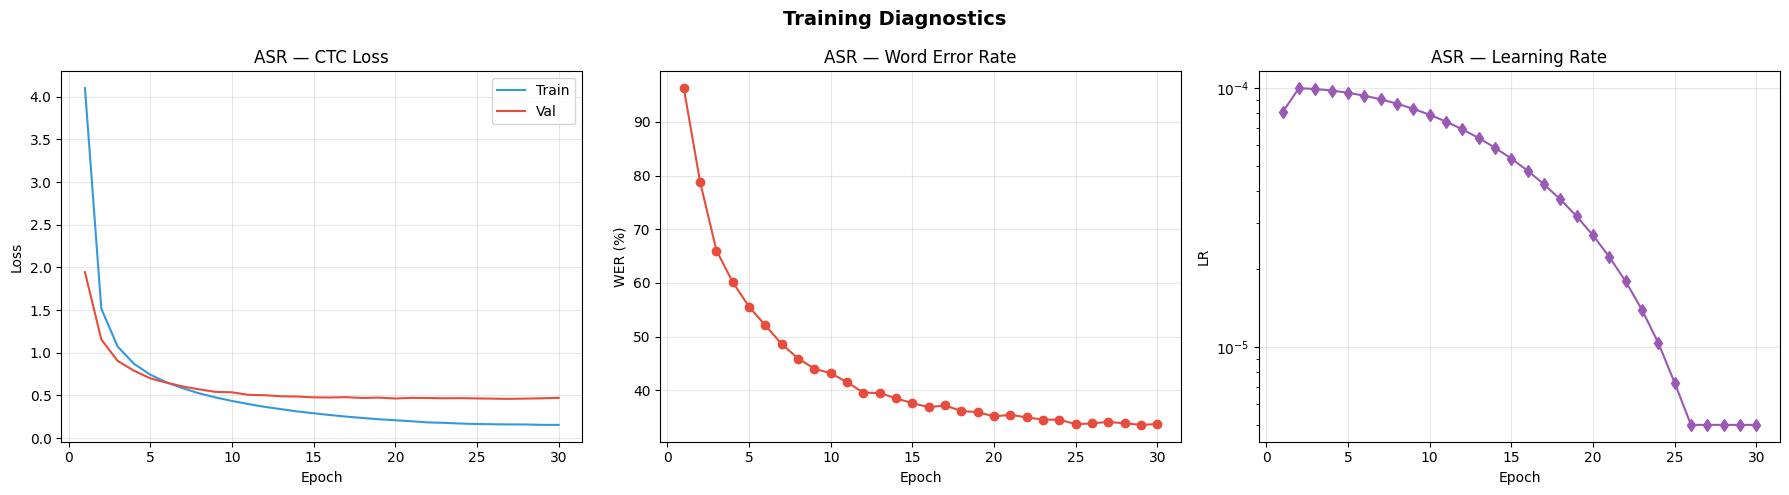

✅ Plot saved → /kaggle/working/output/training_curves.png


In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 21 — Plot Training Curves
# ══════════════════════════════════════════════════════════════
import pandas as pd
import matplotlib.pyplot as plt

asr_log = "/kaggle/working/logs/asr_log.csv"
tts_log = "/kaggle/working/logs/tts_log.csv"

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Diagnostics", fontsize=14, fontweight="bold")

if os.path.exists(asr_log):
    df = pd.read_csv(asr_log)

    # Loss
    axs[0].plot(df["epoch"], df["train_loss"], label="Train", color="#3498db")
    axs[0].plot(df["epoch"], df["val_loss"],   label="Val",   color="#e74c3c")
    axs[0].set_title("ASR — CTC Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(alpha=0.3)

    # WER
    axs[1].plot(df["epoch"], df["val_wer"] * 100,
                color="#e74c3c", marker="o")
    axs[1].set_title("ASR — Word Error Rate")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("WER (%)")
    axs[1].grid(alpha=0.3)

    # LR
    axs[2].plot(df["epoch"], df["lr"], color="#9b59b6", marker="d")
    axs[2].set_title("ASR — Learning Rate")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("LR")
    axs[2].set_yscale("log")
    axs[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = "/kaggle/working/output/training_curves.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved → {plot_path}")


In [ ]:


# ══════════════════════════════════════════════════════════════
# CELL 22 — Package All Outputs for Download
# ══════════════════════════════════════════════════════════════
import zipfile

zip_path = "/kaggle/working/speech_translation_outputs.zip"

with zipfile.ZipFile(zip_path, "w") as zf:
    # Checkpoints
    ckpt_dir = "/kaggle/working/checkpoints"
    for fname in os.listdir(ckpt_dir):
        zf.write(
            os.path.join(ckpt_dir, fname),
            os.path.join("checkpoints", fname),
        )
    # Audio outputs
    out_dir = "/kaggle/working/output"
    for fname in os.listdir(out_dir):
        if fname.endswith(".wav") or fname.endswith(".png"):
            zf.write(
                os.path.join(out_dir, fname),
                os.path.join("output", fname),
            )
    # Logs
    log_dir = "/kaggle/working/logs"
    for fname in os.listdir(log_dir):
        zf.write(
            os.path.join(log_dir, fname),
            os.path.join("logs", fname),
        )

size = os.path.getsize(zip_path) / 1024 / 1024
print(f"✅ Packaged → {zip_path}  ({size:.1f} MB)")
print("   Download from Kaggle Output panel on the right")

✅ Packaged → /kaggle/working/speech_translation_outputs.zip  (352.2 MB)
   Download from Kaggle Output panel on the right
